In [2]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)

### 1. Helper functions to create branch lengths for phylogenetic trees

In [3]:
# helper function to create the branch lengths for a pectinate tree with n tips

pectinate_branch_lengths <- function(n, mu, r) {
    set.seed(r)
    id_branch_lengths = rexp(n - 1, rate = mu)
    branch_lengths = rep(0, 2 * (n - 1))
    branch_lengths[2 * (n - 1)] = id_branch_lengths[n - 1]
    branch_lengths[2 * n - 3] = id_branch_lengths[n - 1]
    for (i in (n - 2):1) {
        branch_lengths[2 * i] = id_branch_lengths[i]
        branch_lengths[2 * i - 1] = branch_lengths[2 * i + 1] +  branch_lengths[2 * i]
    }
    return(branch_lengths)
}

In [4]:
# helper function to create the branch lengths for a balanced tree with n tips

balanced_branch_lengths <- function(n, mu, r) {
    set.seed(r)
    d = log2(n)
    
    id_branch_lengths = rexp(n - 1, rate = mu)
    branch_lengths = rep(0, 2 * (n - 1))
    
    gaps = 1
    for (i in 2:d) {
        gaps = c(gaps, i, gaps)
    }
    gaps = c(0, gaps)
    for (i in 2:length(gaps)) {
        gaps[i] = gaps[i - 1] + gaps[i]
    }
    branches = gaps + d
    branch_lengths[branches] = rep(id_branch_lengths[1:(n / 2)], each = 2)
    t = id_branch_lengths[1:(n / 2)]
    id_branch_lengths = id_branch_lengths[-(1:(n / 2))]

    for (i in (d - 1):1) {
        branches = branches[seq(1, length(branches), by = 2)] - 1
        branch_lengths[branches] = rep(id_branch_lengths[1:(2 ** (i - 1))], each = 2)
        tl = t[seq(1, length(t), by = 2)]
        tr = t[seq(2, length(t), by = 2)]
        t_matrix = matrix(c(tl, tr), nrow = 2, byrow = TRUE)
        t_max = apply(t_matrix, 2, max)
        dt = rep(t_max, each = 2) - t
        branch_lengths[branches] = branch_lengths[branches] + dt
        
        id_branch_lengths = id_branch_lengths[-(1:(2 ** (i - 1)))]
        t = tl + branch_lengths[branches[seq(1, length(branches), by = 2)]]      
    }
    return(branch_lengths)
}

In [180]:
# Yule Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_yule_1 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = sim.bd.taxa(n_tips,1,1,0,1,complete=FALSE)[[1]]
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

        p_vals_PC_yule_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_yule_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_yule_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_yule_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [181]:
p_vals_PC_summary_yule_1 = p_vals_PC_yule_1 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_yule_1 = as.data.table(p_vals_PC_summary_yule_1) 
p_vals_PC_summary_yule_1$method = factor(p_vals_PC_summary_yule_1$method)
p_vals_PC_summary_yule_1$matrix = factor(p_vals_PC_summary_yule_1$matrix)

p_vals_PC_summary_yule_1$method_matrix = interaction(p_vals_PC_summary_yule_1$method, 
                                                     p_vals_PC_summary_yule_1$matrix, 
                                                     sep = "_")

In [183]:
# Pectinate Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_pectinate_1 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = PectinateTree(n_tips)
    tree$edge.length = pectinate_branch_lengths(n_tips, 1, i)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        tryCatch({
            cur_lm = lm(cur_formula,data=all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "lm", "matrix" = "VCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "lm", "matrix" = "VCV")]
            }) 

        counter = counter + 1
        
        tryCatch({
            cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "phylolm", "matrix" = "VCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "phylolm", "matrix" = "VCV")]
            })

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))

        tryCatch({
            cur_lm = lm(cur_formula,data=new_all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "lm", "matrix" = "dcVCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "lm", "matrix" = "dcVCV")]
            })

        counter = counter + 1

        tryCatch({
            cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "phylolm", "matrix" = "dcVCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "phylolm", "matrix" = "dcVCV")]
            })

        counter = counter + 1
    }
}

20

40

60

80



In [10]:
p_vals_PC_summary_pectinate_1 = p_vals_PC_pectinate_1 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_pectinate_1 = as.data.table(p_vals_PC_summary_pectinate_1) 
p_vals_PC_summary_pectinate_1$method = factor(p_vals_PC_summary_pectinate_1$method)
p_vals_PC_summary_pectinate_1$matrix = factor(p_vals_PC_summary_pectinate_1$matrix)

p_vals_PC_summary_pectinate_1$method_matrix = interaction(p_vals_PC_summary_pectinate_1$method, 
                                                          p_vals_PC_summary_pectinate_1$matrix, 
                                                          sep = "_")

In [12]:
# Balanced Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_balanced_1 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = BalancedTree(n_tips)
    tree$edge.length = balanced_branch_lengths(n_tips, 1, i)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

        p_vals_PC_balanced_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_balanced_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_balanced_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_balanced_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [13]:
p_vals_PC_summary_balanced_1 = p_vals_PC_balanced_1 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_balanced_1 = as.data.table(p_vals_PC_summary_balanced_1) 
p_vals_PC_summary_balanced_1$method = factor(p_vals_PC_summary_balanced_1$method)
p_vals_PC_summary_balanced_1$matrix = factor(p_vals_PC_summary_balanced_1$matrix)

p_vals_PC_summary_balanced_1$method_matrix = interaction(p_vals_PC_summary_balanced_1$method, 
                                                         p_vals_PC_summary_balanced_1$matrix, 
                                                         sep = "_")

In [16]:
# Coalescent Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_coal_1 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = rcoal(n_tips)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

        p_vals_PC_coal_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_coal_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_coal_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_coal_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [17]:
p_vals_PC_summary_coal_1 = p_vals_PC_coal_1 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_coal_1 = as.data.table(p_vals_PC_summary_coal_1) 
p_vals_PC_summary_coal_1$method = factor(p_vals_PC_summary_coal_1$method)
p_vals_PC_summary_coal_1$matrix = factor(p_vals_PC_summary_coal_1$matrix)

p_vals_PC_summary_coal_1$method_matrix = interaction(p_vals_PC_summary_coal_1$method, 
                                                     p_vals_PC_summary_coal_1$matrix, 
                                                     sep = "_")

### 2. Scaling effect

In [5]:
num_rep = 500
n_tips = 2 ** c(3:10)
n_PCs = n_tips / 2 - 1
n_PCs[n_PCs > 50] = 50
n_size = length(n_tips)
n_rows = num_rep * (sum(n_PCs) + n_size) * 2

In [6]:
# Yule Trees

p_vals_PC_yule_2 = data.table(
    PCs=numeric(n_rows),
    var.frac=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    tips=numeric(n_rows)
)

counter = 1

for (l in 1:n_size) {
    
    n_tip = n_tips[l]
    num_PC = n_PCs[l]
    message("Testing for size number", l, ":", n_tip, "tips")

    for (i in 1:num_rep) {
        if (i %% 50 == 0) {message(i)}
        
        set.seed(i)
    
        tree = sim.bd.taxa(n_tip,1,1,0,1,complete=FALSE)[[1]]
        tree$root.edge=0
        eigen_decomp = eigen(vcv(tree))
        PCs = eigen_decomp$vectors
        lambdas = eigen_decomp$values
        var_total = sum(lambdas)

        colnames(PCs) = paste0("PC_",1:ncol(PCs))
        PCs = as_tibble(PCs)

        PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
        PC_sets = c("1",PC_sets)   
    
        BM = fastBM(tree,1,nsim=2)
        X = BM[,1]
        Y = BM[,2]
    
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
        rownames(all_data) = rownames(BM)

        var_exp = 0
    
        for (j in 1:length(PC_sets)) {
            if (j > 1) {
                var_exp = var_exp + lambdas[j - 1]
            } 
            var_frac = var_exp / var_total
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
            cur_lm = lm(cur_formula,data=all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
            p_vals_PC_yule_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, var.frac = var_frac,
                                           "method" = "lm", "tips" = n_tip)]
            
            counter = counter + 1
        
            cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_yule_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, var.frac = var_frac,
                                           "method" = "phylolm", "tips" = n_tip)]
            
            counter = counter + 1
        }
    }
    
}

Testing for size number1:8tips

50

100

150

200

250

300

350

400

450

500

Testing for size number2:16tips

50

100

150

200

250

300

350

400

450

500

Testing for size number3:32tips

50

100

150

200

250

300

350

400

450

500

Testing for size number4:64tips

50

100

150

200

250

300

350

400

450

500

Testing for size number5:128tips

50

100

150

200

250

300

350

400

450

500

Testing for size number6:256tips

50

100

150

200

250

300

350

400

450

500

Testing for size number7:512tips

50

100

150

200

250

300

350

400

450

500

Testing for size number8:1024tips

50

100

150

200

250

300

350

400

450

500



In [130]:
p_vals_PC_summary_yule_2 = p_vals_PC_yule_2 %>%
  group_by(method, PCs, tips) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_yule_2 = as.data.table(p_vals_PC_summary_yule_2) 
p_vals_PC_summary_yule_2$tips = factor(p_vals_PC_summary_yule_2$tips)
p_vals_PC_summary_yule_2$method = factor(p_vals_PC_summary_yule_2$method)

fwrite(p_vals_PC_summary_yule_2, file = "p_vals_PC_summary_yule_2.csv")

p_vals_PC_summary_yule_3 = p_vals_PC_yule_2 
p_vals_PC_summary_yule_3$bin = cut(p_vals_PC_summary_yule_3$var.frac, 
                                   breaks = seq(0, 1, by = 0.02), 
                                   labels = 0.02 * (1:50), include.lowest = TRUE)
p_vals_PC_summary_yule_3 = p_vals_PC_summary_yule_3 %>%
  group_by(tips, bin) %>%
  mutate(size = n()) %>%
  ungroup()
p_vals_PC_summary_yule_3 = p_vals_PC_summary_yule_3 %>%
  filter(method == "lm") %>% group_by(bin, tips, size) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(bin = as.numeric(as.character(bin)))

p_vals_PC_summary_yule_3 = as.data.table(p_vals_PC_summary_yule_3) 
p_vals_PC_summary_yule_3$tips = factor(p_vals_PC_summary_yule_3$tips)
# p_vals_PC_summary_yule_3$method = factor(p_vals_PC_summary_yule_3$method)

fwrite(p_vals_PC_summary_yule_3, file = "p_vals_PC_summary_yule_3.csv")

In [83]:
# Pectinate Trees
p_vals_PC_pectinate_2 = data.table(
    PCs=numeric(n_rows),
    var.frac=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    tips=numeric(n_rows)
)

counter = 1

for (l in 1:n_size) {
    
    n_tip = n_tips[l]
    num_PC = n_PCs[l]
    message("Testing for size number", l, ":", n_tip, "tips")

    for (i in 1:num_rep) {
        if (i %% 50 == 0) {message(i)}
        
        set.seed(i)
    
        tree = PectinateTree(n_tip)
        tree$edge.length = pectinate_branch_lengths(n_tip, 1, i)
        tree$root.edge=0
        eigen_decomp = eigen(vcv(tree))
        PCs = eigen_decomp$vectors
        lambdas = eigen_decomp$values
        var_total = sum(lambdas)

        colnames(PCs) = paste0("PC_",1:ncol(PCs))
        PCs = as_tibble(PCs)

        PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
        PC_sets = c("1",PC_sets)   
    
        BM = fastBM(tree,1,nsim=2)
        X = BM[,1]
        Y = BM[,2]
    
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        var_exp = 0
        rownames(all_data) = rownames(BM)
    
        for (j in 1:length(PC_sets)) {
            if (j > 1) {
                var_exp = var_exp + lambdas[j - 1]
            } 
            var_frac = var_exp / var_total
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
            tryCatch({
                cur_lm = lm(cur_formula,data=all_data)
                cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
                p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, var.frac = var_frac, 
                                                    "method" = "lm", "tips" = n_tip)]
                }, error = function(e) {
                p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = NA, var.frac = var_frac, 
                                                    "method" = "lm", "tips" = n_tip)]
                })
            
            counter = counter + 1
        
            tryCatch({
                cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
                cur_p = summary(cur_lm)$coefficients["X","p.value"]
                p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, var.frac = var_frac, 
                                                    "method" = "phylolm", "tips" = n_tip)]
                }, error = function(e) {
                p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = NA, var.frac = var_frac, 
                                                    "method" = "phylolm", "tips" = n_tip)]
                })
            
            counter = counter + 1
        }
    }
}

Testing for size number1:8tips

50

100

150

200

250

300

350

400

450

500

Testing for size number2:16tips

50

100

150

200

250

300

350

400

450

500

Testing for size number3:32tips

50

100

150

200

250

300

350

400

450

500

Testing for size number4:64tips

50

100

150

200

250

300

350

400

450

500

Testing for size number5:128tips

50

100

150

200

250

300

350

400

450

500

Testing for size number6:256tips

50

100

150

200

250

300

350

400

450

500

Testing for size number7:512tips

50

100

150

200

250

300

350

400

450

500

Testing for size number8:1024tips

50

100

150

200

250

300

350

400

450

500



In [142]:
p_vals_PC_summary_pectinate_2 = p_vals_PC_pectinate_2 %>%
  group_by(method, PCs, tips) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_pectinate_2 = as.data.table(p_vals_PC_summary_pectinate_2) 
p_vals_PC_summary_pectinate_2$tips = factor(p_vals_PC_summary_pectinate_2$tips)
p_vals_PC_summary_pectinate_2$method = factor(p_vals_PC_summary_pectinate_2$method)

fwrite(p_vals_PC_summary_pectinate_2, file = "p_vals_PC_summary_pectinate_2.csv")

p_vals_PC_summary_pectinate_3 = p_vals_PC_pectinate_2 
p_vals_PC_summary_pectinate_3$bin = cut(p_vals_PC_summary_pectinate_3$var.frac, 
                                        breaks = seq(0, 1, by = 0.02), 
                                        labels = 0.02 * (1:50), include.lowest = TRUE)
p_vals_PC_summary_pectinate_3 = p_vals_PC_summary_pectinate_3 %>%
  group_by(tips, bin) %>%
  mutate(size = n()) %>%
  ungroup()
p_vals_PC_summary_pectinate_3 = p_vals_PC_summary_pectinate_3 %>%
  filter(method == "lm") %>% group_by(bin, tips, size) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(bin = as.numeric(as.character(bin)))

p_vals_PC_summary_pectinate_3 = as.data.table(p_vals_PC_summary_pectinate_3) 
p_vals_PC_summary_pectinate_3$tips = factor(p_vals_PC_summary_pectinate_3$tips)

fwrite(p_vals_PC_summary_pectinate_3, file = "p_vals_PC_summary_pectinate_3.csv")

In [87]:
# Balanced Trees

p_vals_PC_balance_2 = data.table(
    PCs=numeric(n_rows),
    var.frac=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    tips=numeric(n_rows)
)

counter = 1

for (l in 1:n_size) {
    
    n_tip = n_tips[l]
    num_PC = n_PCs[l]
    message("Testing for size number", l, ":", n_tip, "tips")

    for (i in 1:num_rep) {
        if (i %% 50 == 0) {message(i)}
        
        set.seed(i)
    
        tree = BalancedTree(n_tip)
        tree$edge.length = balanced_branch_lengths(n_tip, 1, i)
        tree$root.edge=0
        eigen_decomp = eigen(vcv(tree))
        PCs = eigen_decomp$vectors
        lambdas = eigen_decomp$values
        var_total = sum(lambdas)

        colnames(PCs) = paste0("PC_",1:ncol(PCs))
        PCs = as_tibble(PCs)

        PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
        PC_sets = c("1",PC_sets)   
    
        BM = fastBM(tree,1,nsim=2)
        X = BM[,1]
        Y = BM[,2]
    
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        var_exp = 0
        rownames(all_data) = rownames(BM)
    
        for (j in 1:length(PC_sets)) {
            if (j > 1) {
                var_exp = var_exp + lambdas[j - 1]
            } 
            var_frac = var_exp / var_total
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
            cur_lm = lm(cur_formula,data=all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
            p_vals_PC_balance_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, var.frac= var_frac,
                                              "method" = "lm", "tips" = n_tip)]
            
            counter = counter + 1
        
            cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_balance_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, var.frac= var_frac,
                                              "method" = "phylolm", "tips" = n_tip)]
            
            counter = counter + 1
        }
    }
}

Testing for size number1:8tips

50

100

150

200

250

300

350

400

450

500

Testing for size number2:16tips

50

100

150

200

250

300

350

400

450

500

Testing for size number3:32tips

50

100

150

200

250

300

350

400

450

500

Testing for size number4:64tips

50

100

150

200

250

300

350

400

450

500

Testing for size number5:128tips

50

100

150

200

250

300

350

400

450

500

Testing for size number6:256tips

50

100

150

200

250

300

350

400

450

500

Testing for size number7:512tips

50

100

150

200

250

300

350

400

450

500

Testing for size number8:1024tips

50

100

150

200

250

300

350

400

450

500



In [154]:
p_vals_PC_summary_balance_2 = p_vals_PC_balance_2 %>%
  group_by(method, PCs, tips) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_balance_2 = as.data.table(p_vals_PC_summary_balance_2) 
p_vals_PC_summary_balance_2$tips = factor(p_vals_PC_summary_balance_2$tips)
p_vals_PC_summary_balance_2$method = factor(p_vals_PC_summary_balance_2$method)

fwrite(p_vals_PC_summary_balance_2, file = "p_vals_PC_summary_balance_2.csv")

p_vals_PC_summary_balance_3 = p_vals_PC_balance_2 
p_vals_PC_summary_balance_3$bin = cut(p_vals_PC_summary_balance_3$var.frac, 
                                        breaks = seq(0, 1, by = 0.02), 
                                        labels = 0.02 * (1:50), include.lowest = TRUE)
p_vals_PC_summary_balance_3 = p_vals_PC_summary_balance_3 %>%
  group_by(tips, bin) %>%
  mutate(size = n()) %>%
  ungroup()
p_vals_PC_summary_balance_3 = p_vals_PC_summary_balance_3 %>%
  filter(method == "lm") %>% group_by(bin, tips, size) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(bin = as.numeric(as.character(bin)))

p_vals_PC_summary_balance_3 = as.data.table(p_vals_PC_summary_balance_3) 
p_vals_PC_summary_balance_3$tips = factor(p_vals_PC_summary_balance_3$tips)

fwrite(p_vals_PC_summary_balance_3, file = "p_vals_PC_summary_balance_3.csv")

In [91]:
# Coalescent Trees
p_vals_PC_coal_2 = data.table(
    PCs=numeric(n_rows),
    var.frac=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    tips=numeric(n_rows)
)

counter = 1

for (l in 1:n_size) {
    
    n_tip = n_tips[l]
    num_PC = n_PCs[l]
    message("Testing for size number", l, ":", n_tip, "tips")

    for (i in 1:num_rep) {
        if (i %% 50 == 0) {message(i)}
        
        set.seed(i)
    
        tree = rcoal(n_tip)
        tree$root.edge=0
        eigen_decomp = eigen(vcv(tree))
        PCs = eigen_decomp$vectors
        lambdas = eigen_decomp$values
        var_total = sum(lambdas)

        colnames(PCs) = paste0("PC_",1:ncol(PCs))
        PCs = as_tibble(PCs)

        PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
        PC_sets = c("1",PC_sets)   
    
        BM = fastBM(tree,1,nsim=2)
        X = BM[,1]
        Y = BM[,2]
    
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        var_exp = 0
        rownames(all_data) = rownames(BM)
    
        for (j in 1:length(PC_sets)) {
            if (j > 1) {
                var_exp = var_exp + lambdas[j - 1]
            } 
            var_frac = var_exp / var_total
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
            cur_lm = lm(cur_formula,data=all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
            p_vals_PC_coal_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, var.frac = var_frac,
                                           "method" = "lm", "tips" = n_tip)]
            
            counter = counter + 1
        
            cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_coal_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, var.frac = var_frac,
                                           "method" = "phylolm", "tips" = n_tip)]
            
            counter = counter + 1
        }
    }
    
}

Testing for size number1:8tips

50

100

150

200

250

300

350

400

450

500

Testing for size number2:16tips

50

100

150

200

250

300

350

400

450

500

Testing for size number3:32tips

50

100

150

200

250

300

350

400

450

500

Testing for size number4:64tips

50

100

150

200

250

300

350

400

450

500

Testing for size number5:128tips

50

100

150

200

250

300

350

400

450

500

Testing for size number6:256tips

50

100

150

200

250

300

350

400

450

500

Testing for size number7:512tips

50

100

150

200

250

300

350

400

450

500

Testing for size number8:1024tips

50

100

150

200

250

300

350

400

450

500



In [155]:
p_vals_PC_summary_coal_2 = p_vals_PC_coal_2 %>%
  group_by(method, PCs, tips) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_coal_2 = as.data.table(p_vals_PC_summary_coal_2) 
p_vals_PC_summary_coal_2$tips = factor(p_vals_PC_summary_coal_2$tips)
p_vals_PC_summary_coal_2$method = factor(p_vals_PC_summary_coal_2$method)

fwrite(p_vals_PC_summary_coal_2, file = "p_vals_PC_summary_coal_2.csv")

p_vals_PC_summary_coal_3 = p_vals_PC_coal_2 
p_vals_PC_summary_coal_3$bin = cut(p_vals_PC_summary_coal_3$var.frac, 
                                   breaks = seq(0, 1, by = 0.02), 
                                   labels = 0.02 * (1:50), include.lowest = TRUE)
p_vals_PC_summary_coal_3 = p_vals_PC_summary_coal_3 %>%
  group_by(tips, bin) %>%
  mutate(size = n()) %>%
  ungroup()
p_vals_PC_summary_coal_3 = p_vals_PC_summary_coal_3 %>%
  filter(method == "lm") %>% group_by(bin, tips, size) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(bin = as.numeric(as.character(bin)))

p_vals_PC_summary_coal_3 = as.data.table(p_vals_PC_summary_coal_3) 
p_vals_PC_summary_coal_3$tips = factor(p_vals_PC_summary_coal_3$tips)

fwrite(p_vals_PC_summary_coal_3, file = "p_vals_PC_summary_coal_3.csv")

### 3. Plotting

In [175]:
plot_5 <- p_vals_PC_summary_yule_2 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = tips, linetype = method), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.8),legend.spacing.y = unit(1,"pt"), 
        legend.key.width = unit(2, "cm")) +
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024")) +
  scale_linetype_manual(values = c("solid", "twodash"), breaks = c("OLS", "PGLS"))

In [176]:
plot_6 <- p_vals_PC_summary_pectinate_2 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = tips, linetype = method), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.8),legend.spacing.y = unit(1,"pt"), 
        legend.key.width = unit(2, "cm")) +
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024")) +
  scale_linetype_manual(values = c("solid", "twodash"), breaks = c("OLS", "PGLS"))

In [177]:
plot_7 <- p_vals_PC_summary_balance_2 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = tips, linetype = method), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.8),legend.spacing.y = unit(1,"pt"), 
        legend.key.width = unit(2, "cm")) +
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024")) +
  scale_linetype_manual(values = c("solid", "twodash"), breaks = c("OLS", "PGLS"))

In [178]:
plot_8 <- p_vals_PC_summary_coal_2 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = tips, linetype = method), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.8),legend.spacing.y = unit(1,"pt"), 
        legend.key.width = unit(2, "cm")) +
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024")) +
  scale_linetype_manual(values = c("solid", "twodash"), breaks = c("OLS", "PGLS"))

Warning message:
“Removed 106 rows containing missing values or values outside the scale range (`geom_line()`).”


TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]
2 2 (2-2,1-1) arrange gtable[arrange]

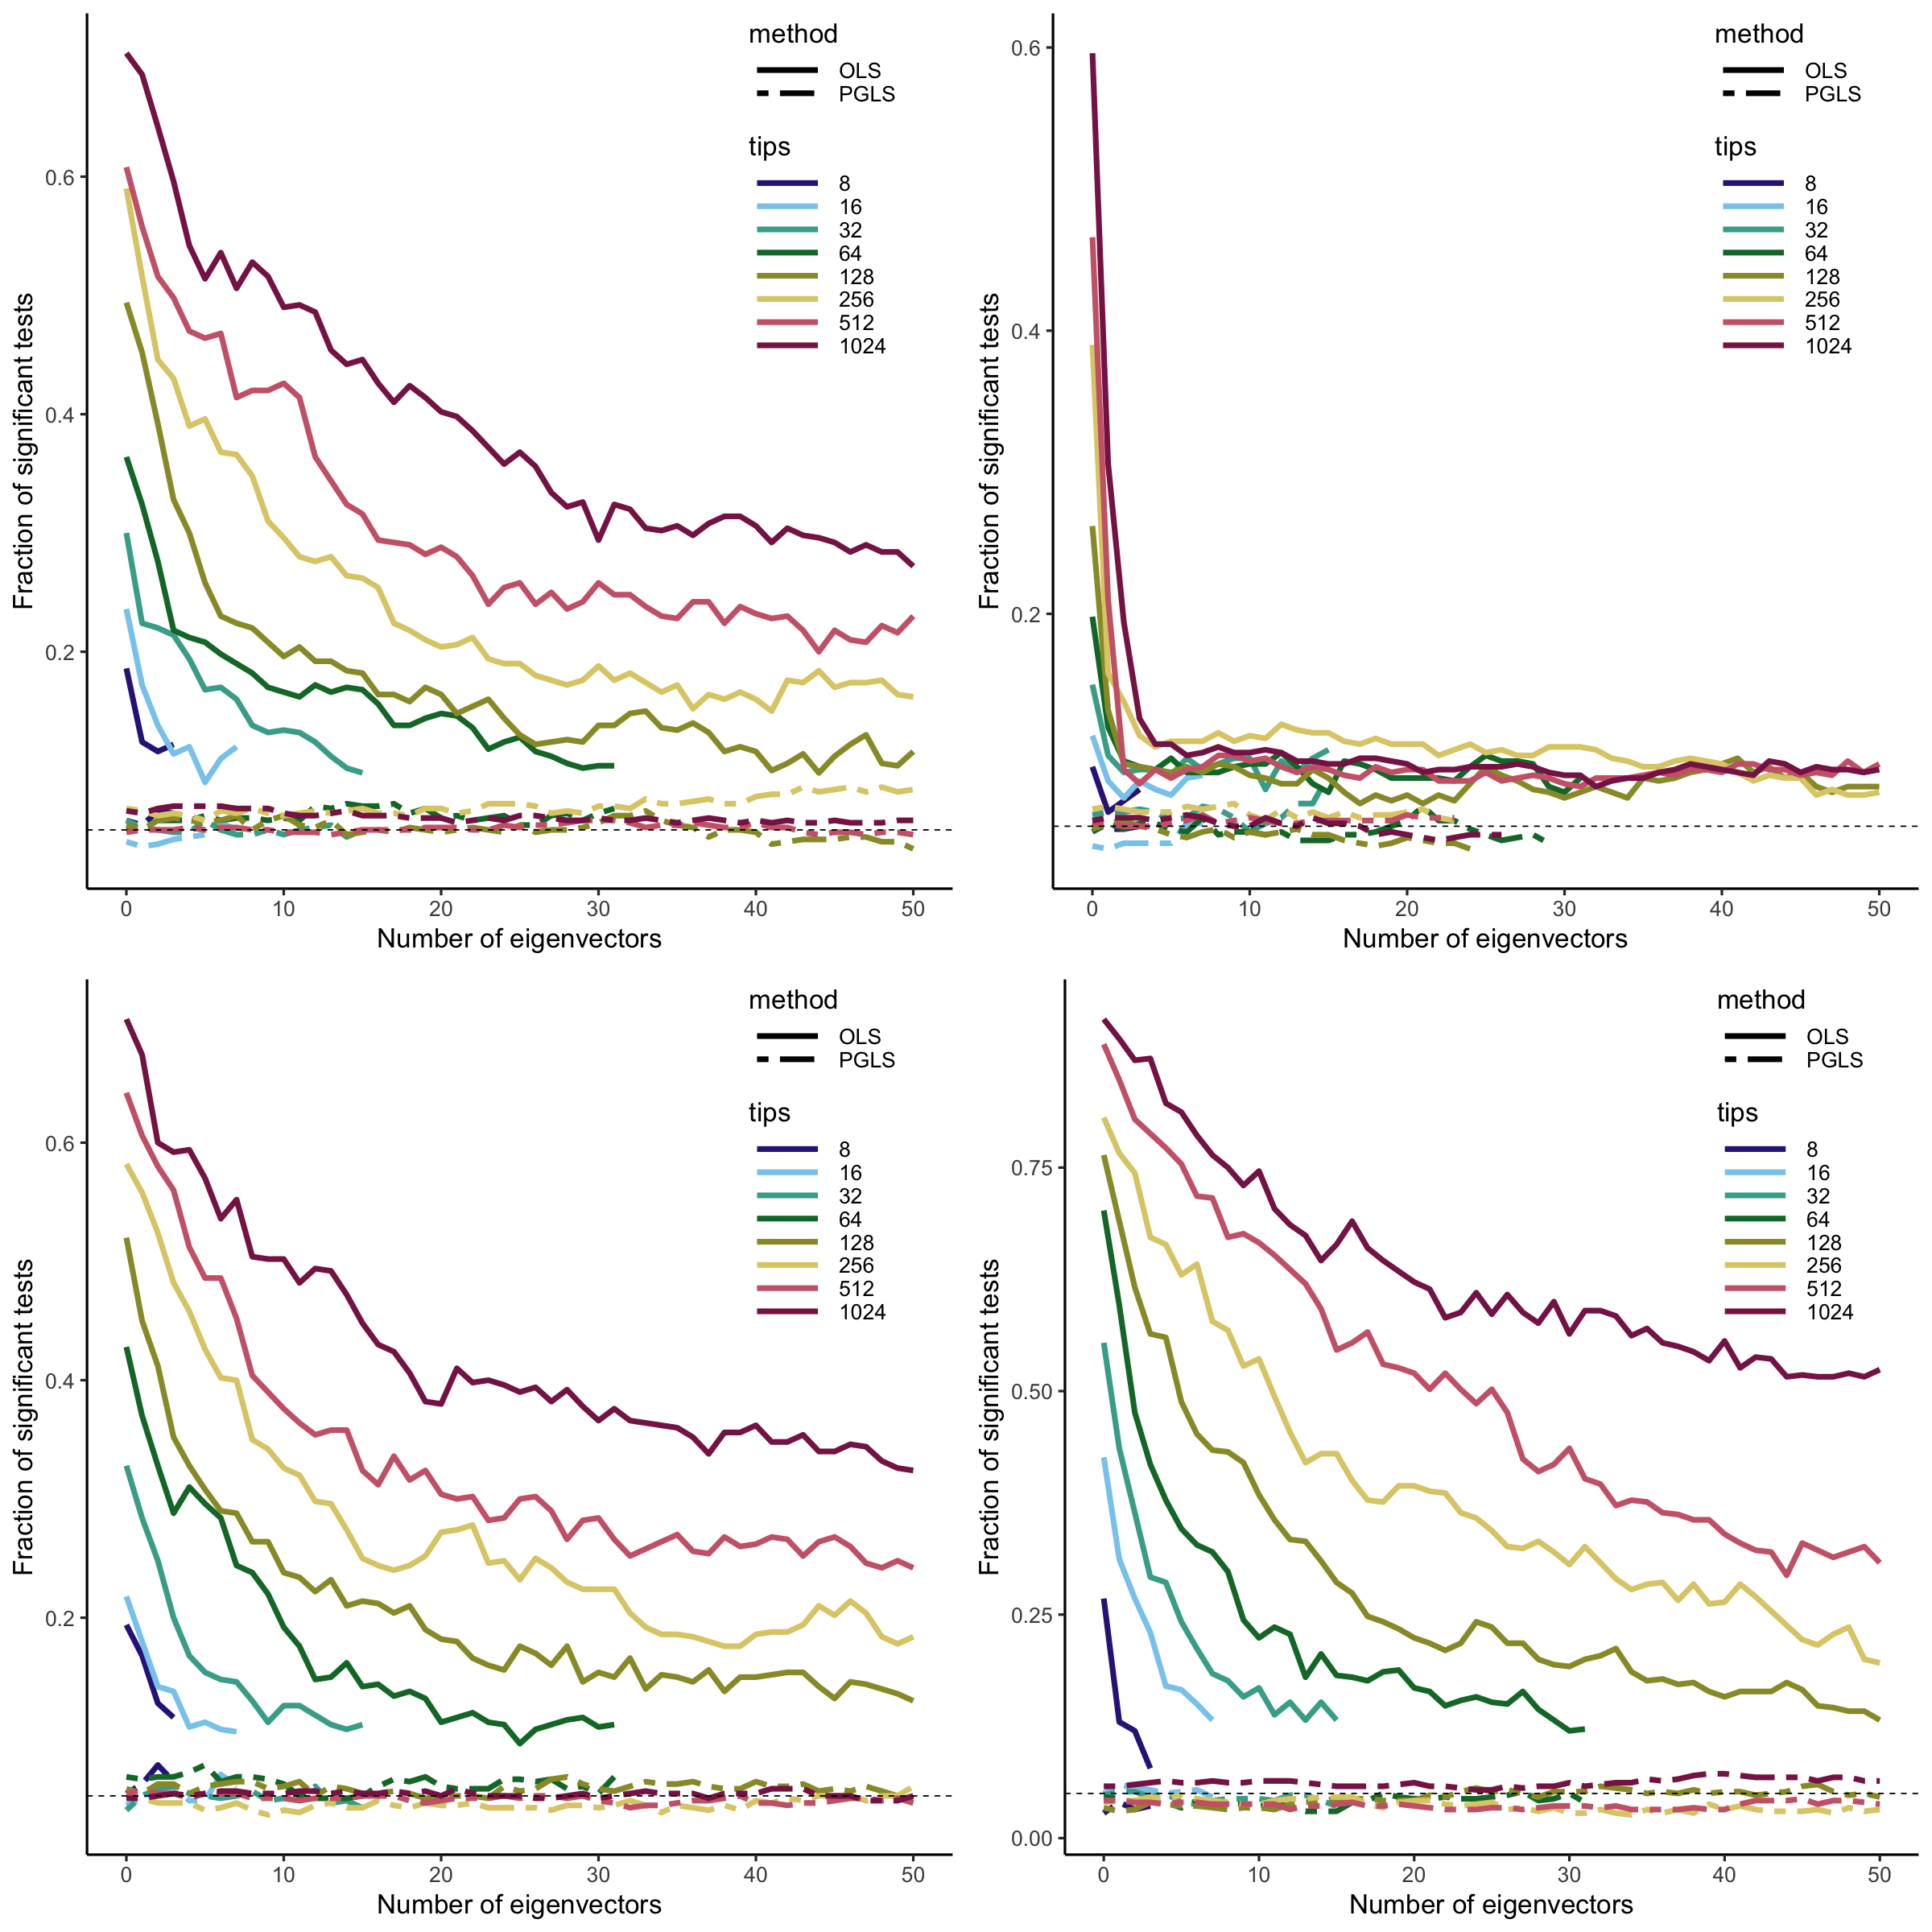

In [179]:
options(repr.plot.width = 20, repr.plot.height = 20)

row1 <- arrangeGrob(plot_5, plot_6, ncol = 2)
row2 <- arrangeGrob(plot_7, plot_8, ncol = 2)

# Arrange all rows into one layout
g <- grid.arrange(row1, row2, nrow = 2)
g
ggsave("Figures_raw/Figure_2_raw.pdf", g, width = 20, height = 20)
ggsave("Figures_raw/Figure_2_raw.svg", g, width = 20, height = 20)

### Extra work

In [186]:
plot_9 <- p_vals_PC_summary_yule_3 %>% 
  ggplot(aes(bin, FPR)) +
  geom_point(aes(color = tips, size = size)) +
  theme_classic(base_size=20) +
  xlab("Fraction of cumulative explained variance") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.75), legend.spacing.y = unit(1,"pt"),
        legend.key.size = unit(4, "pt")) +
  labs(size = "trees") + 
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024"))

plot_10 <- p_vals_PC_summary_pectinate_3 %>% 
  ggplot(aes(bin, FPR)) +
  geom_point(aes(color = tips, size = size)) +
  theme_classic(base_size=20) +
  xlab("Fraction of cumulative explained variance") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.75), legend.spacing.y = unit(1,"pt"),
        legend.key.size = unit(4, "pt")) +
  labs(size = "trees") + 
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024"))

plot_11 <- p_vals_PC_summary_balance_3 %>% 
  ggplot(aes(bin, FPR)) +
  geom_point(aes(color = tips, size = size)) +
  theme_classic(base_size=20) +
  xlab("Fraction of cumulative explained variance") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.75), legend.spacing.y = unit(1,"pt"),
        legend.key.size = unit(4, "pt")) +
  labs(size = "trees") + 
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024"))

plot_12 <- p_vals_PC_summary_coal_3 %>% 
  ggplot(aes(bin, FPR)) +
  geom_point(aes(color = tips, size = size)) +
  theme_classic(base_size=20) +
  xlab("Fraction of cumulative explained variance") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.75), legend.spacing.y = unit(1,"pt"),
        legend.key.size = unit(4, "pt")) +
  labs(size = "trees") + 
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024")) +
  guides(
    color = guide_legend(order = 1),
    size  = guide_legend(order = 2)
  )

In [168]:
plot_10 <- p_vals_PC_summary_pectinate_3 %>% 
  ggplot(aes(bin, FPR)) +
  geom_point(aes(color = tips, size = size)) +
  theme_classic(base_size=20) +
  xlab("Fraction of cumulative explained variance") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.75), legend.spacing.y = unit(1,"pt"),
        legend.key.size = unit(4, "pt")) +
  labs(size = "trees") + 
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024"))

plot_10 <- p_vals_PC_summary_pectinate_3 %>% 
  ggplot(aes(bin, FPR)) +
  geom_line(aes(color = tips), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Fraction of cumulative explained variance") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.8),legend.spacing.y = unit(1,"pt"), 
        legend.key.width = unit(2, "cm")) +
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024"))

TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]
2 2 (2-2,1-1) arrange gtable[arrange]

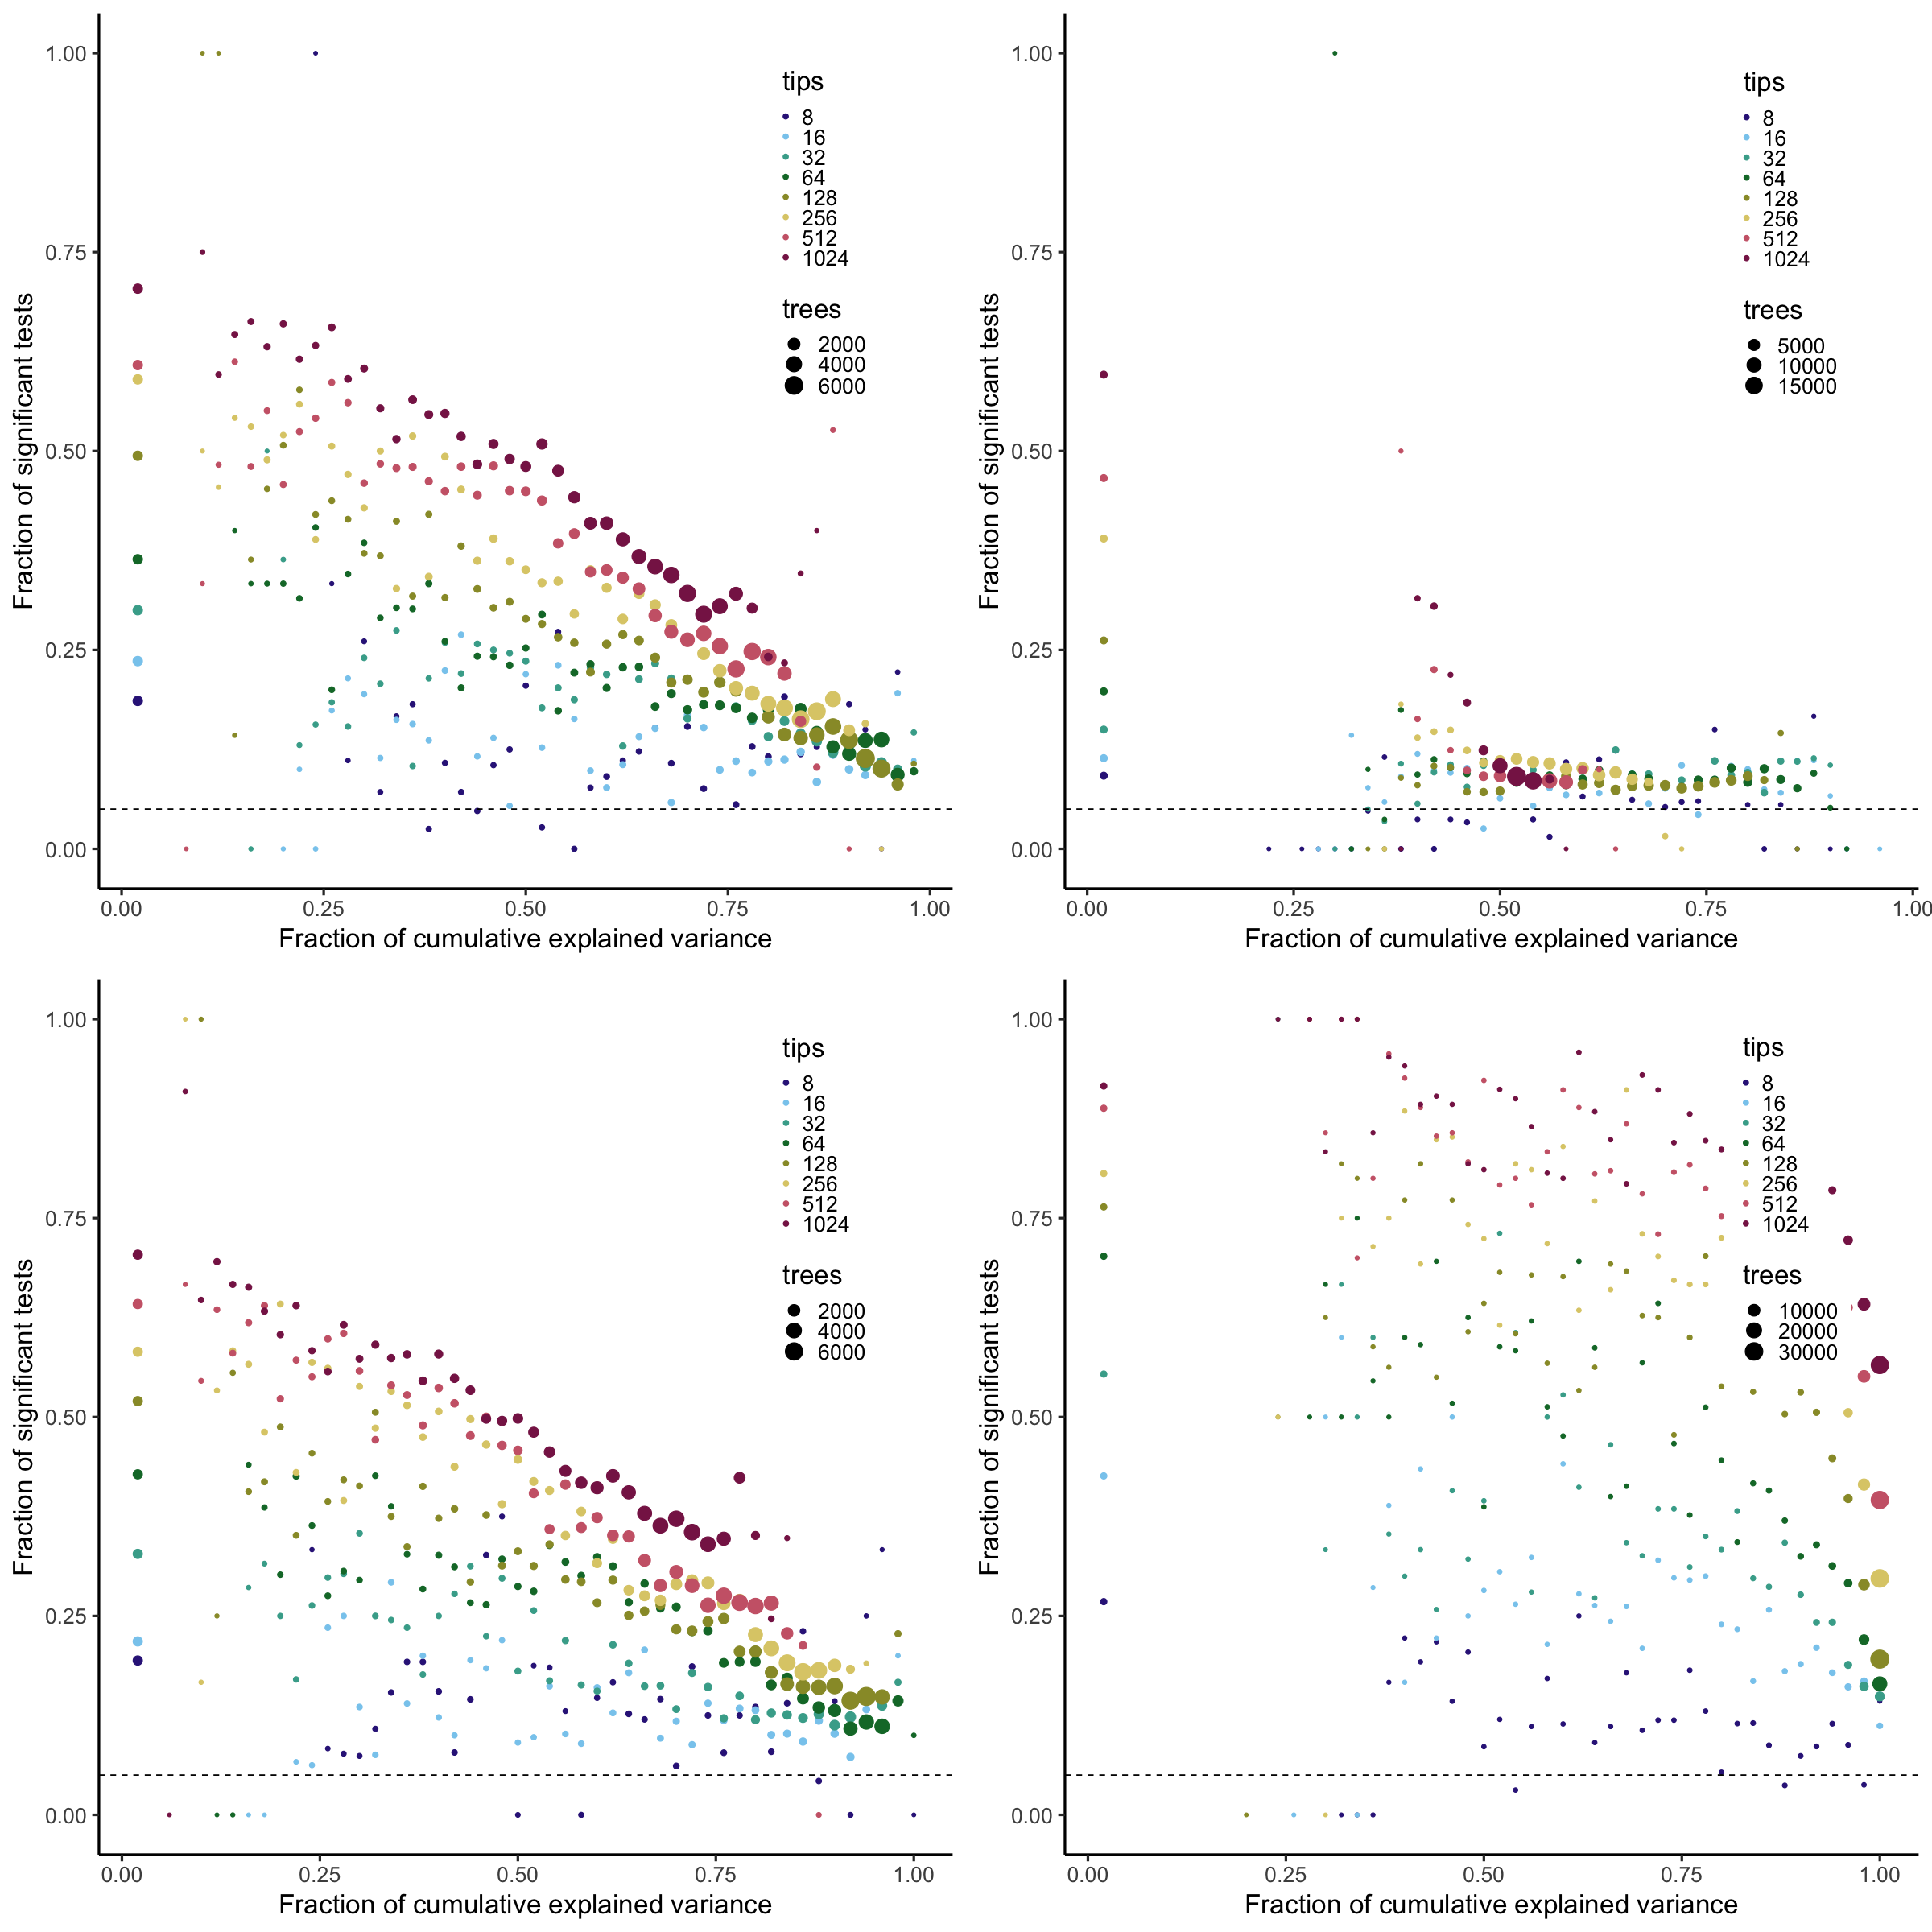

In [187]:
options(repr.plot.width = 20, repr.plot.height = 20)

row1 <- arrangeGrob(plot_9, plot_10, ncol = 2)
row2 <- arrangeGrob(plot_11, plot_12, ncol = 2)

# Arrange all rows into one layout
g <- grid.arrange(row1, row2, nrow = 2)
g
ggsave("Figures_raw/Figure_2_alt.pdf", g, width = 20, height = 20)
ggsave("Figures_raw/Figure_2_alt.svg", g, width = 20, height = 20)